# Bleed-through removal on historical manuscripts

**Goal.** Turn a manuscript scan into a black-and-white mask that keeps only the **front-side ink** and treats bleed-through (ghost ink from the back of the page) as background. That is what the DIBCO ground truth (GT) marks.

**Structure**
1. Setup and data
2. How results are scored
3. **Approaches we tried:** 9 methods, from simple thresholds to bleed-through-aware pipelines
4. **Comparison and conclusion:** which approach works best across all images
5. **Our technique, step by step:** background normalisation → Otsu → edge gate
6. Errors against the GT
7. Saved outputs
8. Observations

**Images.** Every image in `joeal_data/<dataset>/images/` that has a matching `gt/<name>_gt.png` is used, currently DIBCO 2009, H-DIBCO 2010 and H-DIBCO 2014. To add another page, drop it and its GT into the same layout and re-run.

## 1. Setup and data

In [1]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import (threshold_otsu, threshold_yen, threshold_sauvola,
                             threshold_niblack, threshold_multiotsu, apply_hysteresis_threshold)
from skimage.morphology import skeletonize, remove_small_objects
from sklearn.mixture import GaussianMixture

# Works whether the notebook is run from joeal project/ or joeal project/joeal_notebooks/
DATA = next(p for p in [Path('joeal_data'), Path('../joeal_data')] if p.exists())
OUT = DATA / 'output'
OUT.mkdir(parents=True, exist_ok=True)

def find_images():
    """Every joeal_data/<dataset>/images/<name>.png that has a joeal_data/<dataset>/gt/<name>_gt.png."""
    found = {}
    for img_path in sorted(DATA.glob('*/images/*.png')):
        gt_path = img_path.parent.parent / 'gt' / f'{img_path.stem}_gt.png'
        if gt_path.exists():
            folder = img_path.parent.parent
            found[f'{folder.name}/{img_path.stem}'] = (folder, img_path.stem)
    return found

def load(folder, name):
    img = cv2.imread(str(folder / 'images' / f'{name}.png'), cv2.IMREAD_GRAYSCALE)
    gt = cv2.imread(str(folder / 'gt' / f'{name}_gt.png'), cv2.IMREAD_GRAYSCALE) == 0   # True = text
    skel_path = folder / 'gt' / f'{name}_skel.png'      # official skeleton GT, if the dataset ships one
    skel = cv2.imread(str(skel_path), cv2.IMREAD_GRAYSCALE) == 0 if skel_path.exists() else None
    return img, gt, skel

SOURCES = find_images()
IMAGES = list(SOURCES)
data = {label: load(*src) for label, src in SOURCES.items()}
for n, (img, gt, skel) in data.items():
    print(f'{n}: {img.shape}, text in GT = {gt.mean():.2%}, official skeleton: {skel is not None}')

dibco2009/H02: (1366, 946), text in GT = 2.16%, official skeleton: False
dibco2009/H03: (492, 582), text in GT = 9.70%, official skeleton: False
hdibco2010/H05: (391, 1726), text in GT = 5.78%, official skeleton: True
hdibco2014/H01: (707, 1761), text in GT = 5.68%, official skeleton: False
hdibco2014/H02: (455, 1881), text in GT = 8.23%, official skeleton: False
hdibco2014/H07: (436, 1449), text in GT = 8.82%, official skeleton: False
hdibco2014/H08: (688, 1925), text in GT = 3.03%, official skeleton: False
hdibco2014/H09: (482, 1474), text in GT = 9.82%, official skeleton: False
hdibco2014/H10: (407, 1498), text in GT = 9.82%, official skeleton: False


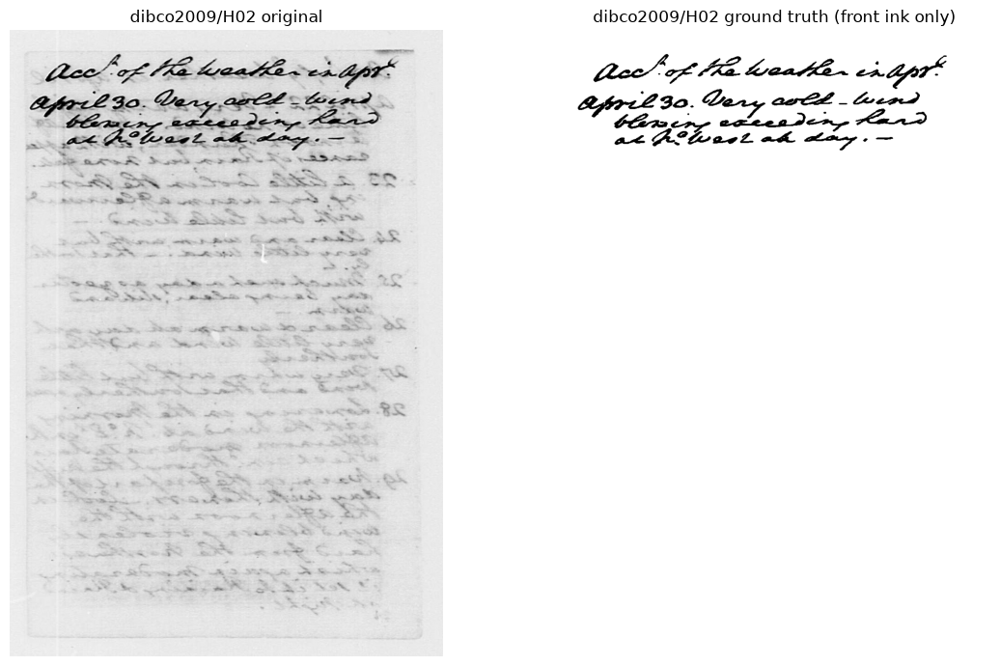

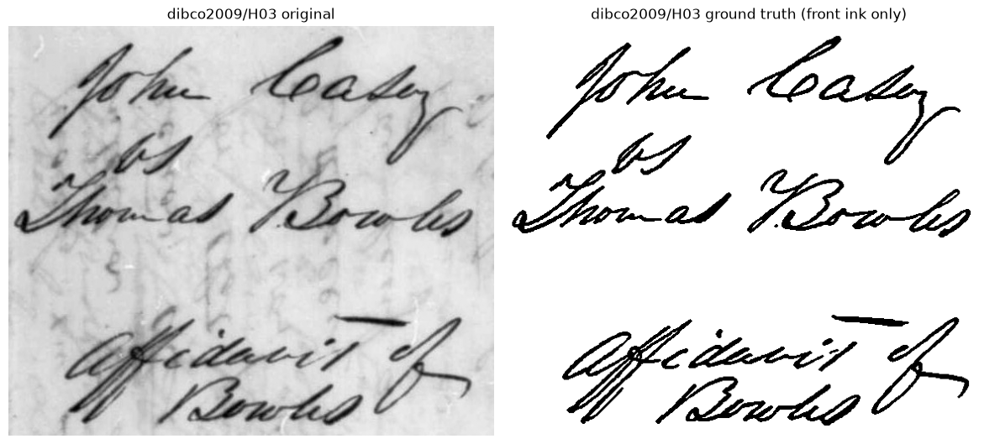

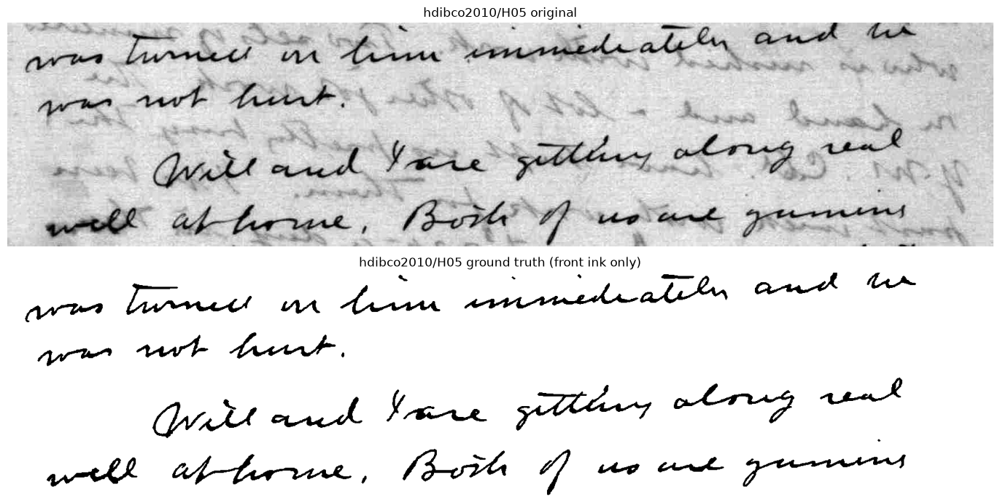

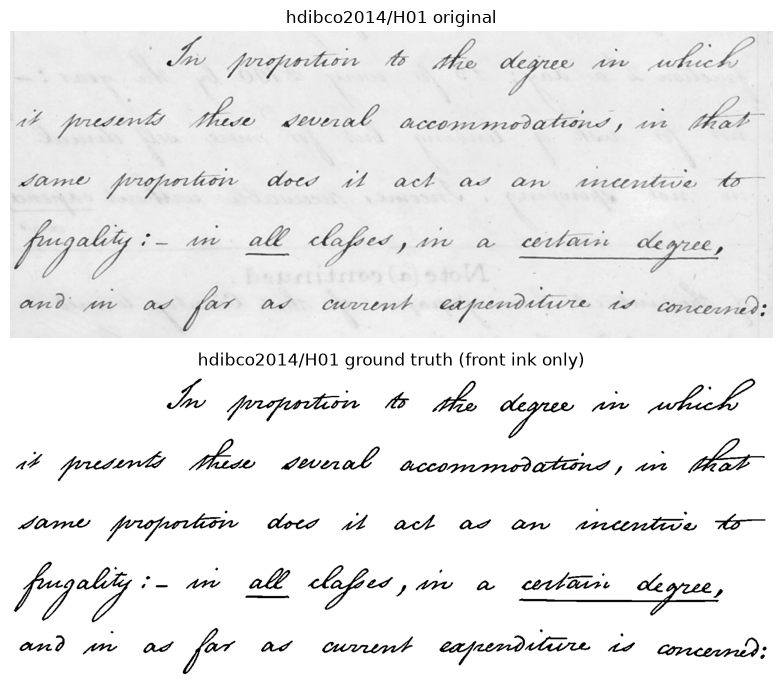

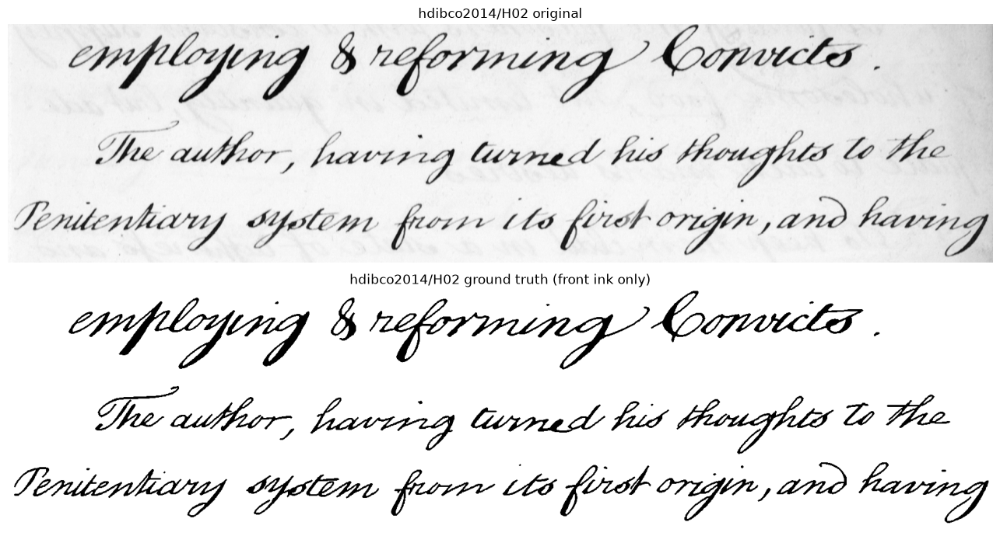

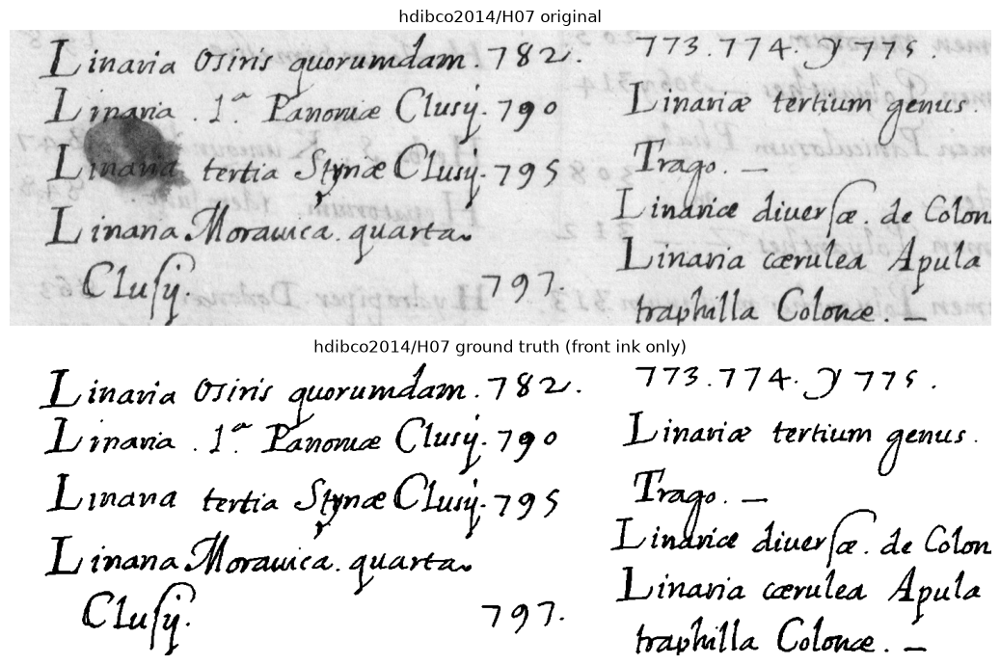

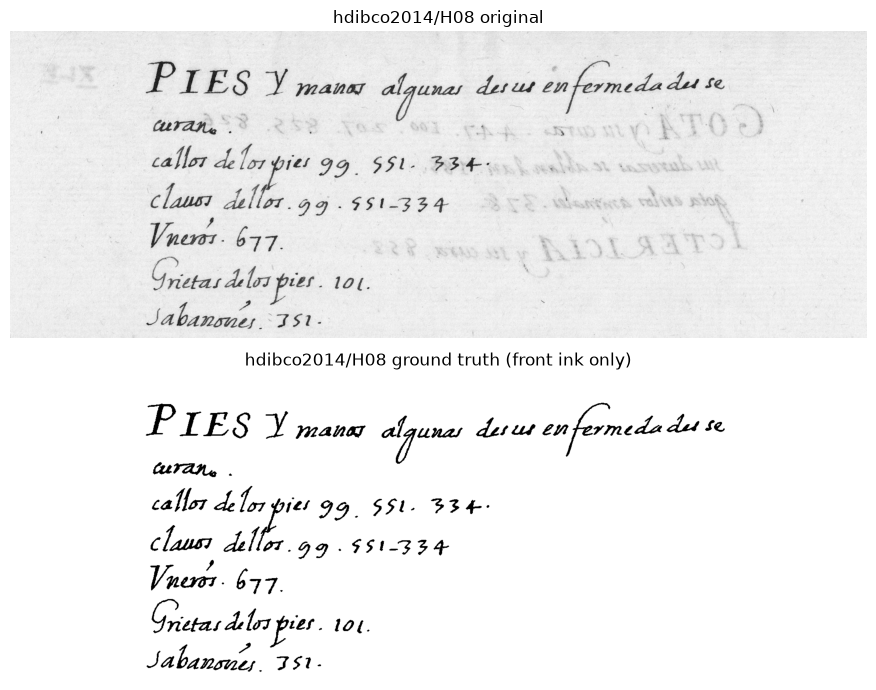

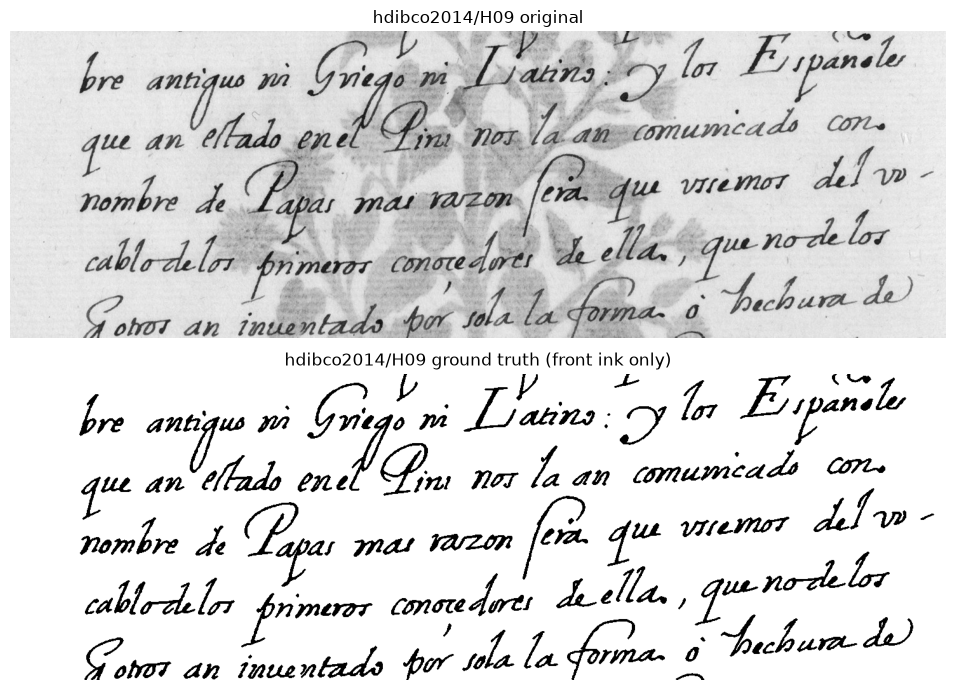

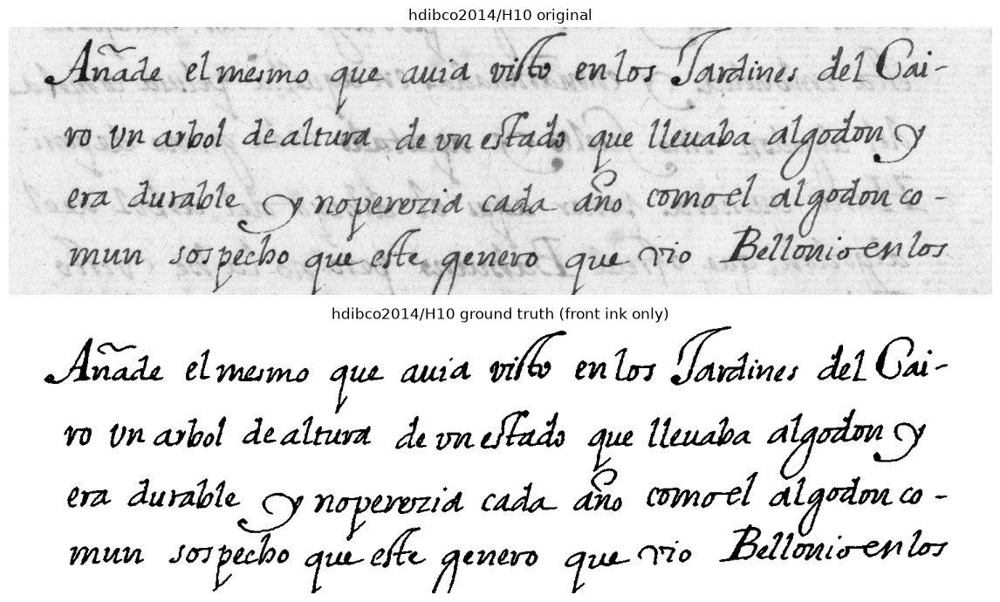

In [2]:
def is_wide(img):
    return img.shape[1] > 2 * img.shape[0]

for n in IMAGES:
    img, gt, _ = data[n]
    fig, ax = plt.subplots(2, 1, figsize=(14, 7)) if is_wide(img) else plt.subplots(1, 2, figsize=(12, 7))
    ax[0].imshow(img, cmap='gray'); ax[0].set_title(f'{n} original')
    ax[1].imshow(~gt, cmap='gray'); ax[1].set_title(f'{n} ground truth (front ink only)')
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()

## 2. Evaluation metrics

| Measure | Meaning | Better |
|---|---|---|
| **F-measure** | pixel-level precision/recall of text pixels | higher |
| **pseudo-F (pF)** | recall on the GT *skeleton*, so broken strokes cost more than blurry edges | higher |
| **PSNR** | closeness of the binary image to the GT | higher |
| **DRD** | Distance Reciprocal Distortion, an error weighted by human perception | lower |

`True` = text in every binary array.

- **F-measure**: `2·P·R / (P+R)` over text pixels.
- **pseudo-F**: same precision, but recall = fraction of **GT skeleton** pixels detected. Uses the official skeleton when the dataset provides one (H-DIBCO 2010); otherwise it is computed with `skeletonize`.
- **PSNR**: `10·log10(1 / MSE)` with a pixel difference of 0 or 1.
- **DRD** (Lu et al. 2004): every flipped pixel costs the inverse-distance-weighted count of disagreeing GT pixels in a 5×5 window. The total is divided by the number of non-uniform 8×8 GT blocks.

In [3]:
_i, _j = np.mgrid[-2:3, -2:3]
W_DRD = np.where((_i == 0) & (_j == 0), 0, 1 / np.sqrt(np.maximum(_i**2 + _j**2, 1)))
W_DRD /= W_DRD.sum()

def drd(pred, gt):
    nbr = cv2.filter2D(gt.astype(float), -1, W_DRD, borderType=cv2.BORDER_CONSTANT)
    cost = np.where(pred, 1 - nbr, nbr)          # weighted disagreement with GT neighbours
    total = cost[pred != gt].sum()
    H, W = gt.shape
    blocks = gt[:H // 8 * 8, :W // 8 * 8].reshape(H // 8, 8, W // 8, 8).sum(axis=(1, 3))
    nubn = np.count_nonzero((blocks != 0) & (blocks != 64))
    return total / max(nubn, 1)

def evaluate(pred, gt, skel=None):
    p, g = pred.astype(bool), gt.astype(bool)
    tp = np.count_nonzero(p & g); fp = np.count_nonzero(p & ~g); fn = np.count_nonzero(~p & g)
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    f = 2 * prec * rec / max(prec + rec, 1e-12)
    skel = skeletonize(g) if skel is None else skel
    p_rec = np.count_nonzero(p & skel) / max(np.count_nonzero(skel), 1)
    pf = 2 * prec * p_rec / max(prec + p_rec, 1e-12)
    mse = np.mean(p != g)
    psnr = 10 * np.log10(1 / mse) if mse > 0 else np.inf
    return {'F': 100 * f, 'pF': 100 * pf, 'PSNR': psnr, 'DRD': drd(p, g)}

img, gt, _ = data[IMAGES[0]]; print('GT vs itself:', evaluate(gt, gt))

GT vs itself: {'F': np.float64(100.0), 'pF': np.float64(100.0), 'PSNR': inf, 'DRD': np.float64(0.0)}


## 3. Approaches we tried

**Global thresholds:** one cut-off for the whole page.
- **Otsu:** picks the grey level that best separates two groups of pixels. Simple, but uneven lighting and dark bleed-through break the "two groups" assumption.
- **Yen:** picks the threshold that maximises the entropy (information) of the two classes. Tends to keep too much.

**Local thresholds:** a different cut-off for each neighbourhood (25×25 window).
- **Niblack:** threshold = local mean − k·local std. Keeps lots of noise on blank paper.
- **Sauvola:** Niblack adapted for documents, so it is quieter on plain background. But next to bleed-through, the ghost ink is locally the darkest thing, so it gets kept.
- **Wolf:** Sauvola normalised by the global contrast of the page. More stable across pages.

**Bleed-through aware:** first flatten the background (divide by an estimate of the bare paper), then separate front ink from ghost ink.
- **BgNorm + Otsu:** global Otsu on the flattened page.
- **BgNorm + GMM:** a Gaussian mixture model with 3 clusters (ink / bleed / paper). Keep the darkest cluster.
- **BgNorm + Hysteresis:** start from confidently dark "seed" pixels and grow into weaker ink only where it touches a seed.
- **BgNorm + Otsu + Edge gate (ours):** BgNorm + Otsu, then drop blobs with blurry edges, because bleed-through is seen through paper and is soft.

All parameters are fixed and identical for every image.

In [4]:
# --- building blocks + our technique ---
PARAMS = dict(
    close_size=31,       # step 1: closing kernel, larger than any stroke width
    median_size=21,      # step 1: smooths the background estimate
    min_speck=30,        # step 2: components of this many pixels or fewer are removed
    canny=(60, 150),     # step 3: Canny thresholds on the original image
    min_edge_ratio=0.08, # step 3: edge pixels / component size needed to count as real ink
)

def bg_normalise(gray, close_size, median_size):
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_size, close_size))
    background = cv2.medianBlur(cv2.morphologyEx(gray, cv2.MORPH_CLOSE, se), median_size)
    norm = np.clip(gray.astype(float) / np.maximum(background, 1) * 255, 0, 255).astype(np.uint8)
    return norm, background

def edge_gate(binary, gray, canny, min_edge_ratio):
    edges = cv2.Canny(cv2.GaussianBlur(gray, (3, 3), 0), *canny) > 0
    nl, lab = cv2.connectedComponents(binary.astype(np.uint8), connectivity=8)
    edge_cnt = np.bincount(lab[edges], minlength=nl)
    size = np.bincount(lab.ravel(), minlength=nl)
    keep = edge_cnt / np.maximum(size, 1) > min_edge_ratio
    keep[0] = False                                   # label 0 is background
    return keep[lab], edges

def binarize(gray, p=PARAMS):
    norm, background = bg_normalise(gray, p['close_size'], p['median_size'])          # step 1
    t = threshold_otsu(norm)
    thresh = remove_small_objects(norm < t, max_size=p['min_speck'])                  # step 2
    final, edges = edge_gate(thresh, gray, p['canny'], p['min_edge_ratio'])           # step 3
    return final, dict(background=background, normalised=norm, otsu_t=t,
                       thresholded=thresh, edges=edges, removed_by_gate=thresh & ~final)

In [5]:
# --- the other approaches ---
def wolf(gray, w=25, k=0.5):
    g = gray.astype(float)
    m = cv2.boxFilter(g, -1, (w, w))
    s = np.sqrt(np.maximum(cv2.boxFilter(g * g, -1, (w, w)) - m * m, 0))
    R, M = s.max(), g.min()
    return g < (1 - k) * m + k * M + k * (s / R) * (m - M)

def normalised(gray):
    return bg_normalise(gray, PARAMS['close_size'], PARAMS['median_size'])[0]

def clean(binary):
    return remove_small_objects(binary, max_size=PARAMS['min_speck'])

def bg_otsu(gray):
    n = normalised(gray)
    return clean(n < threshold_otsu(n))

def bg_gmm(gray, seed=0):
    n = normalised(gray).astype(float).reshape(-1, 1)
    sample = n[np.random.default_rng(seed).choice(len(n), 50_000, replace=False)]
    gm = GaussianMixture(3, random_state=seed).fit(sample)
    ink = np.argmin(gm.means_[:, 0])                       # darkest cluster
    return clean((gm.predict_proba(n)[:, ink] > 0.5).reshape(gray.shape))

def bg_hysteresis(gray):
    n = normalised(gray)
    t_dark, _ = threshold_multiotsu(n, 3)                   # confident ink
    t_otsu = threshold_otsu(n)                              # weaker ink, kept only if connected
    inv = 255 - n.astype(float)
    return clean(apply_hysteresis_threshold(inv, 255 - t_otsu, 255 - t_dark))

OURS = 'BgNorm+Otsu+EdgeGate (ours)'
METHODS = {
    'Otsu':                lambda g: g < threshold_otsu(g),
    'Yen':                 lambda g: g < threshold_yen(g),
    'Niblack':             lambda g: g < threshold_niblack(g, 25, 0.2),
    'Sauvola':             lambda g: g < threshold_sauvola(g, 25, 0.2),
    'Wolf':                wolf,
    'BgNorm+Otsu':         bg_otsu,
    'BgNorm+GMM':          bg_gmm,
    'BgNorm+Hysteresis':   bg_hysteresis,
    OURS:                  lambda g: binarize(g)[0],
}

## 4. Comparison across all images

Every method is run on every image and scored against the GT.

In [6]:
rows = []
for n in IMAGES:
    img, gt, skel = data[n]
    for name, fn in METHODS.items():
        rows.append({'image': n, 'method': name, **evaluate(fn(img), gt, skel)})
all_scores = pd.DataFrame(rows)

summary = all_scores.groupby('method')[['F', 'pF', 'PSNR', 'DRD']].mean().round(2)
summary['worst F'] = all_scores.groupby('method')['F'].min().round(2)
summary['images won (F)'] = (all_scores.loc[all_scores.groupby('image')['F'].idxmax(), 'method']
                             .value_counts().reindex(summary.index, fill_value=0))
summary = summary.sort_values('F', ascending=False)
print('Mean over all images:')
summary

Mean over all images:


,F,pF,PSNR,DRD,worst F,images won (F)
method,,,,,,
BgNorm+Otsu+EdgeGate (ours),90.74,94.66,19.67,2.57,85.09,1
BgNorm+Hysteresis,90.65,94.55,19.62,2.61,85.05,0
BgNorm+Otsu,90.60,94.52,19.59,2.64,85.16,0
Wolf,89.45,94.21,19.26,3.02,80.30,0
Otsu,88.47,92.24,18.58,3.90,84.10,0
BgNorm+GMM,86.17,88.21,18.39,5.44,72.22,5
Sauvola,85.75,90.12,18.05,6.46,64.87,1
Yen,81.17,82.11,16.25,12.06,45.57,2
Niblack,35.67,36.05,6.39,113.88,12.30,0


In [7]:
# F-measure per image
f_table = all_scores.pivot(index='method', columns='image', values='F').round(1)
f_table.loc[summary.index]

image,dibco2009/H02,dibco2009/H03,hdibco2010/H05,hdibco2014/H01,hdibco2014/H02,hdibco2014/H07,hdibco2014/H08,hdibco2014/H09,hdibco2014/H10
method,,,,,,,,,
BgNorm+Otsu+EdgeGate (ours),91.3,88.1,93.0,88.8,85.1,91.4,92.8,93.4,92.9
BgNorm+Hysteresis,91.2,88.0,92.9,88.5,85.1,91.3,92.8,93.4,92.7
BgNorm+Otsu,91.2,87.6,92.7,88.8,85.2,91.2,92.8,93.4,92.7
Wolf,88.0,88.4,91.7,80.3,86.2,91.3,93.6,93.4,92.1
Otsu,86.4,84.5,88.8,88.4,86.2,84.1,93.0,92.2,92.6
BgNorm+GMM,72.2,75.5,93.1,87.7,72.6,92.1,94.9,94.4,93.1
Sauvola,64.9,88.5,74.9,86.1,88.5,90.9,92.9,93.2,91.9
Yen,45.6,79.3,73.9,91.3,88.6,82.2,90.9,90.3,88.5
Niblack,12.3,47.9,31.0,29.7,39.3,47.0,15.7,48.4,49.8


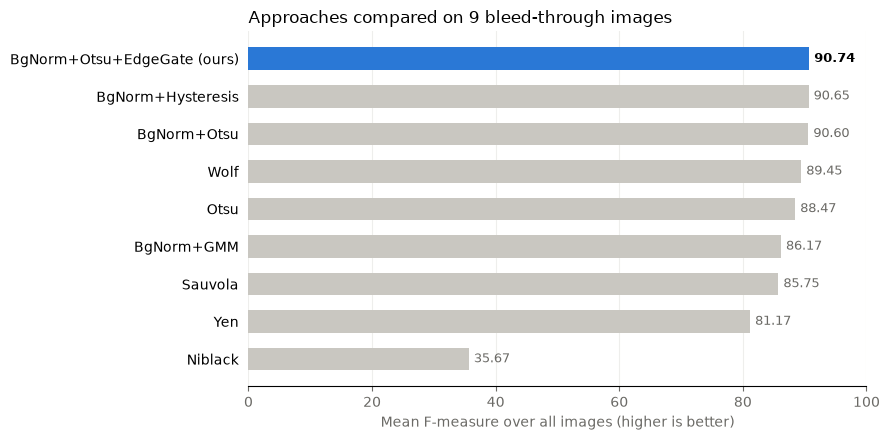

In [8]:
ACCENT, OTHER, MUTED = '#2a78d6', '#c9c7c1', '#6b6a66'
order = summary.sort_values('F').index
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [ACCENT if m == OURS else OTHER for m in order]
ax.barh(order, summary.loc[order, 'F'], color=colors, height=0.6)
for y, m in enumerate(order):
    v = summary.loc[m, 'F']
    ax.text(v + 0.8, y, f'{v:.2f}', va='center', fontsize=9,
            color='black' if m == OURS else MUTED, fontweight='bold' if m == OURS else 'normal')
ax.set_xlim(0, 100)
ax.set_xlabel('Mean F-measure over all images (higher is better)', color=MUTED)
ax.set_title(f'Approaches compared on {len(IMAGES)} bleed-through images', loc='left')
for side in ('top', 'right', 'left'): ax.spines[side].set_visible(False)
ax.tick_params(left=False, colors=MUTED); ax.tick_params(axis='y', labelcolor='black')
ax.xaxis.grid(True, color='#eeeeec'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### Conclusion

**We chose BgNorm + Otsu + Edge gate** because it is the best *all-rounder*:

- **Highest mean score** on every measure across the 9 pages (F 90.7, pF 94.7, DRD 2.57).
- **Consistent:** its worst page is F 85.1, level with the other BgNorm pipelines. Every method that wins individual pages has a bad page somewhere.
  - GMM tops 5 pages but drops to F 72 on the DIBCO 2009 pages.
  - Sauvola drops to F 65 on dibco2009/H02.
  - Yen and Wolf drop to F 46 and F 80.
- **What drives it:** background normalisation is what lifts it above plain thresholds. The three BgNorm pipelines are within 0.14 F of each other, and the edge gate adds a small but consistent final gain.

For an unknown manuscript page, a method that never fails badly is worth more than one that is occasionally best.

## 5. Our technique, step by step

**Step 1 – Background normalisation**
- *What:* a large morphological closing wipes out the dark strokes and leaves an estimate of the bare paper. Dividing the image by that estimate flattens it.
- *Why:* stains, yellowing and uneven lighting disappear, so ink stands out against a uniform white page.
- *Effect:* +2.1 F on average over plain Otsu, and up to +7 F on pages with heavy bleed-through or uneven paper (e.g. hdibco2014/H07, dibco2009/H02). It has almost no effect on already-clean pages.

**Step 2 – Otsu threshold + speck removal**
- *What:* Otsu automatically picks the grey level that best splits pixels into two groups (ink vs. paper). Blobs of 30 px or fewer are then deleted.
- *Why:* after flattening, front ink is the darkest thing on the page, so a single global threshold separates it well. The speck filter removes noise.

**Step 3 – Edge gate**
- *What:* run Canny edge detection on the original image. Keep a blob only if enough of its pixels are edges (ratio > 0.08).
- *Why:* bleed-through is seen *through* the paper, so it is blurred and has weak edges. Real ink is sharp.
- *Effect:* small. It removes 0–5 ghost blobs per page (+0.14 F on average).

Below: each image after every step. In the last panel, blobs removed by the edge gate are **orange**.

In [9]:
results, preds, steps = [], {}, {}
for n in IMAGES:
    img, gt, skel = data[n]
    preds[n], steps[n] = binarize(img)
    results.append({'image': n, **evaluate(preds[n], gt, skel),
                    'F after step 2': evaluate(steps[n]['thresholded'], gt, skel)['F'],
                    'blobs removed by gate': cv2.connectedComponents(
                        steps[n]['removed_by_gate'].astype(np.uint8))[0] - 1})
scores = pd.DataFrame(results).set_index('image').round(2)
scores

,F,pF,PSNR,DRD,F after step 2,blobs removed by gate
image,,,,,,
dibco2009/H02,91.26,94.10,24.14,3.26,91.19,1
dibco2009/H03,88.06,89.22,16.00,3.90,87.58,5
hdibco2010/H05,93.02,94.57,20.79,2.06,92.72,5
hdibco2014/H01,88.76,94.61,19.30,2.79,88.76,0
hdibco2014/H02,85.09,86.16,16.64,3.99,85.16,1
hdibco2014/H07,91.40,97.29,18.44,2.01,91.19,4
hdibco2014/H08,92.77,98.74,23.84,1.71,92.77,0
hdibco2014/H09,93.38,98.82,19.08,1.61,93.36,1
hdibco2014/H10,92.90,98.41,18.77,1.76,92.69,2


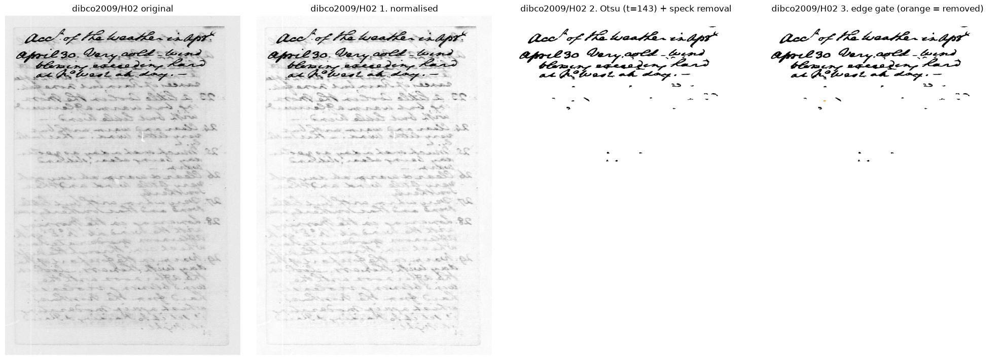

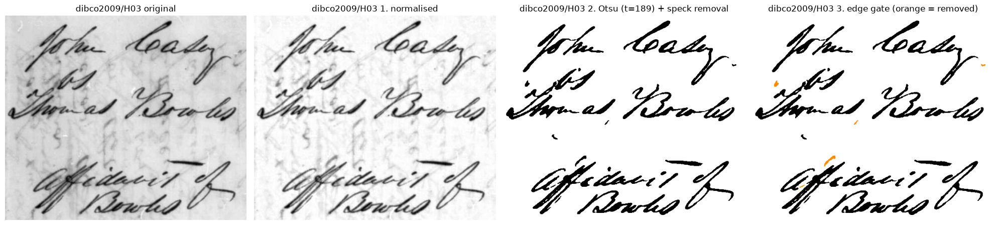

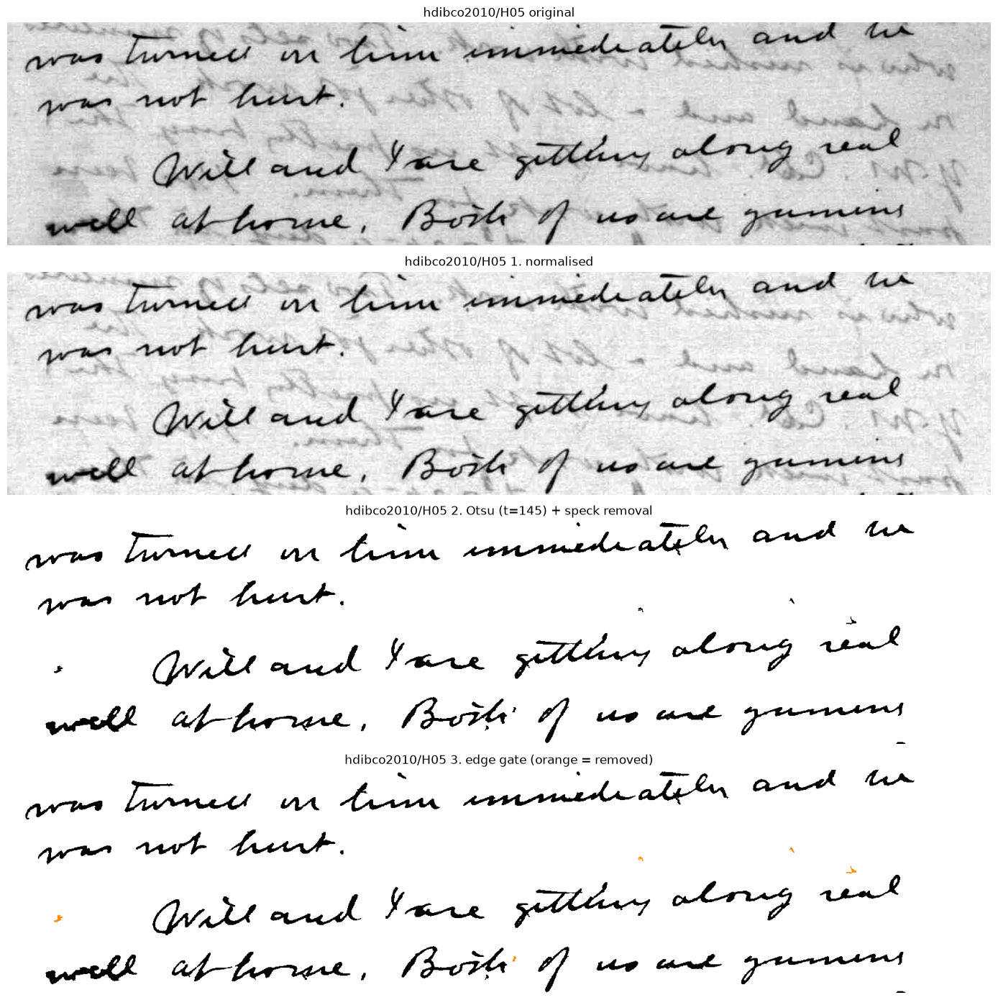

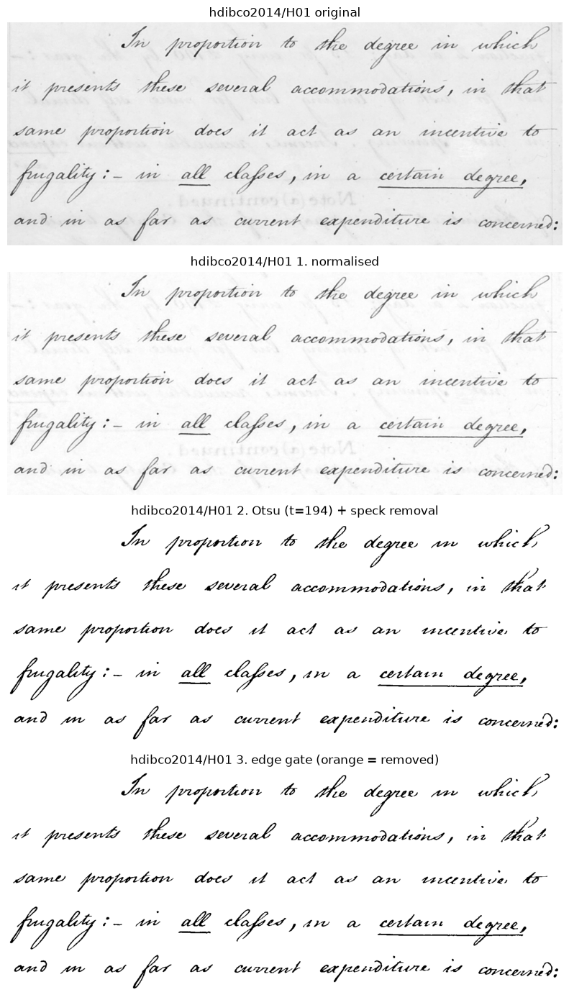

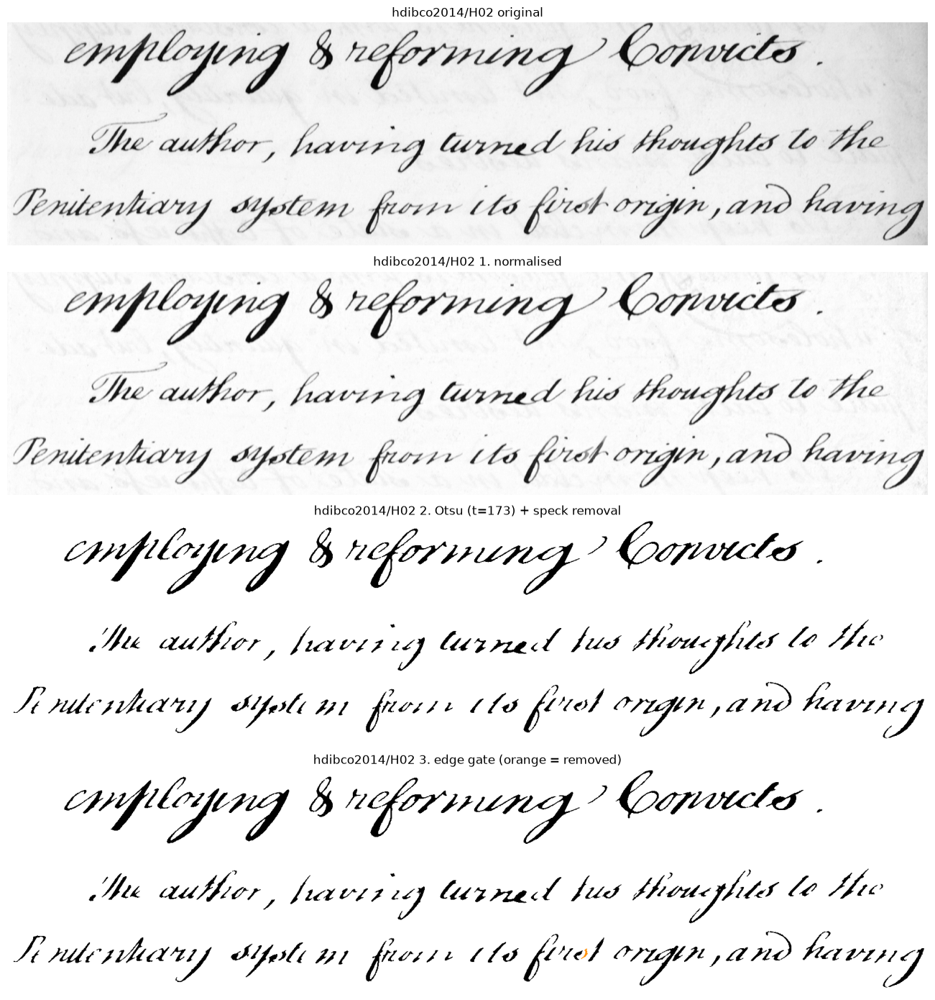

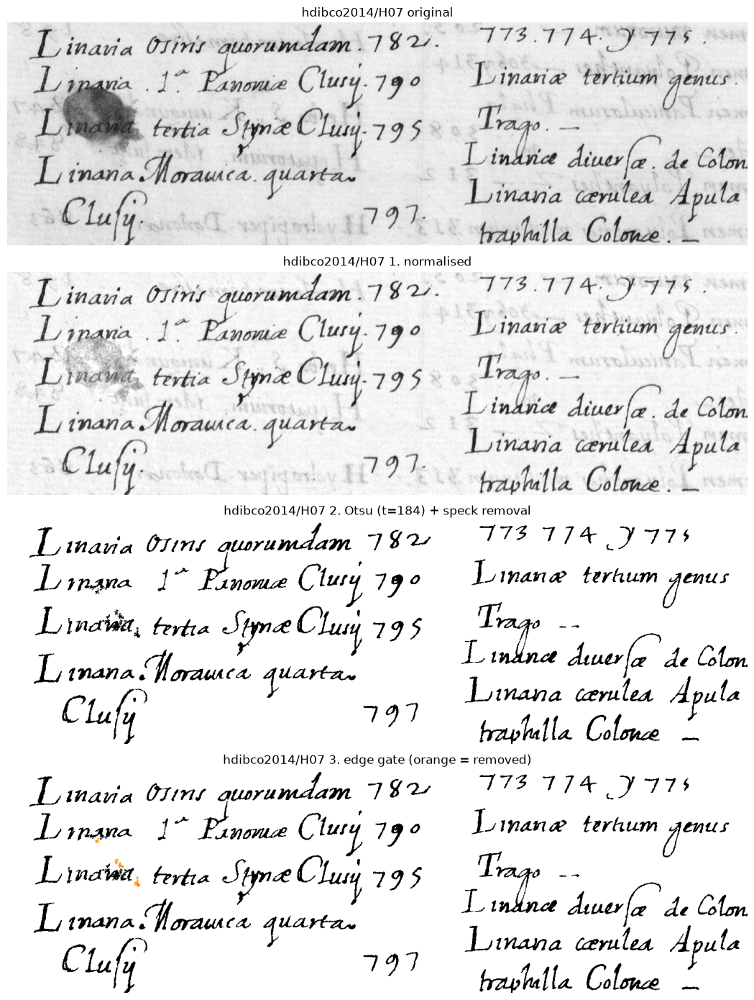

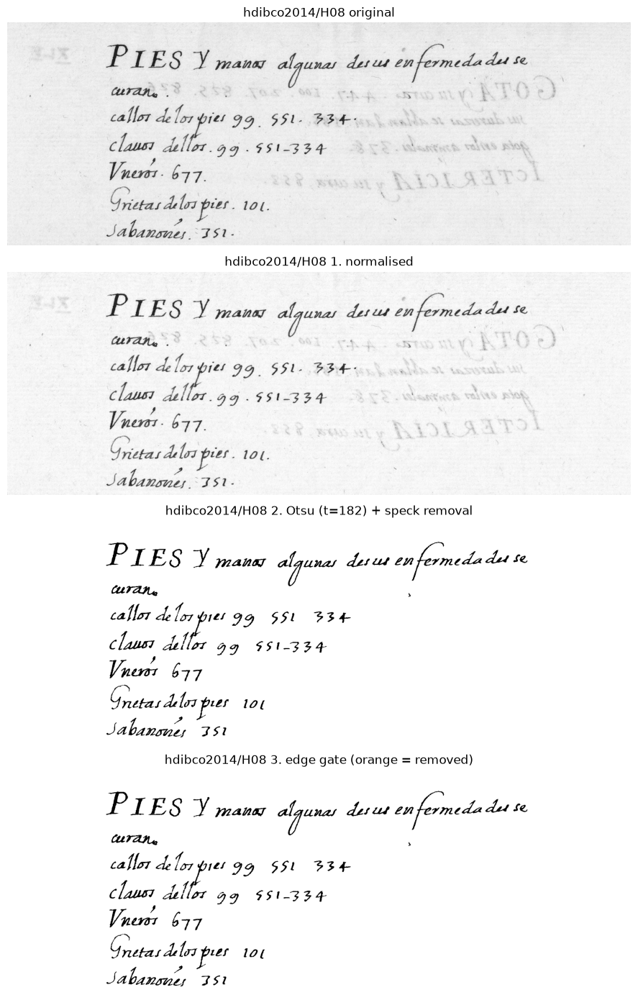

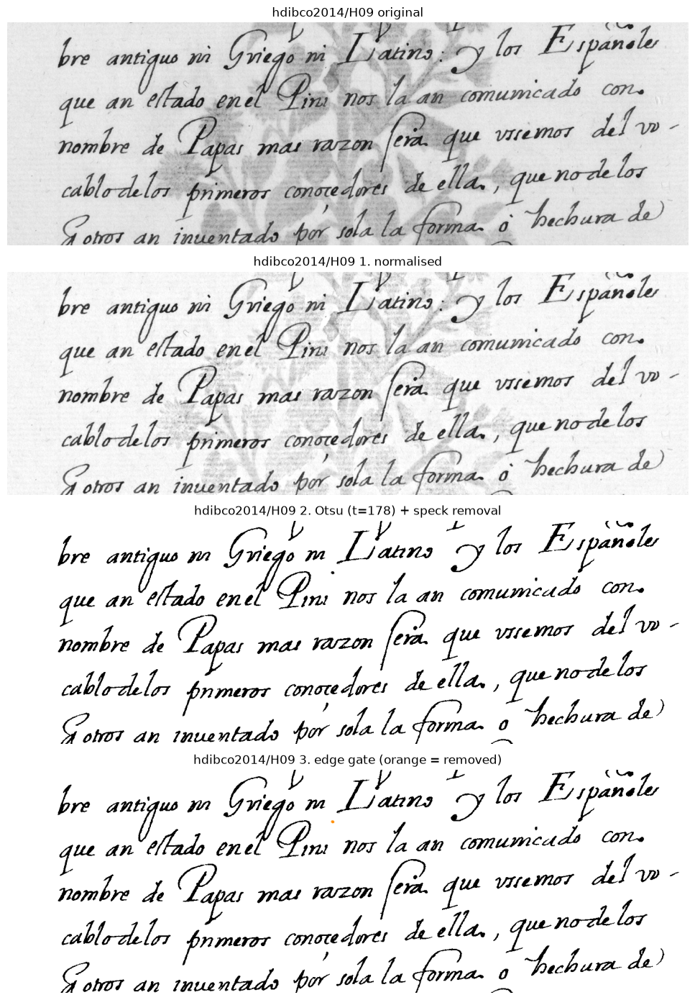

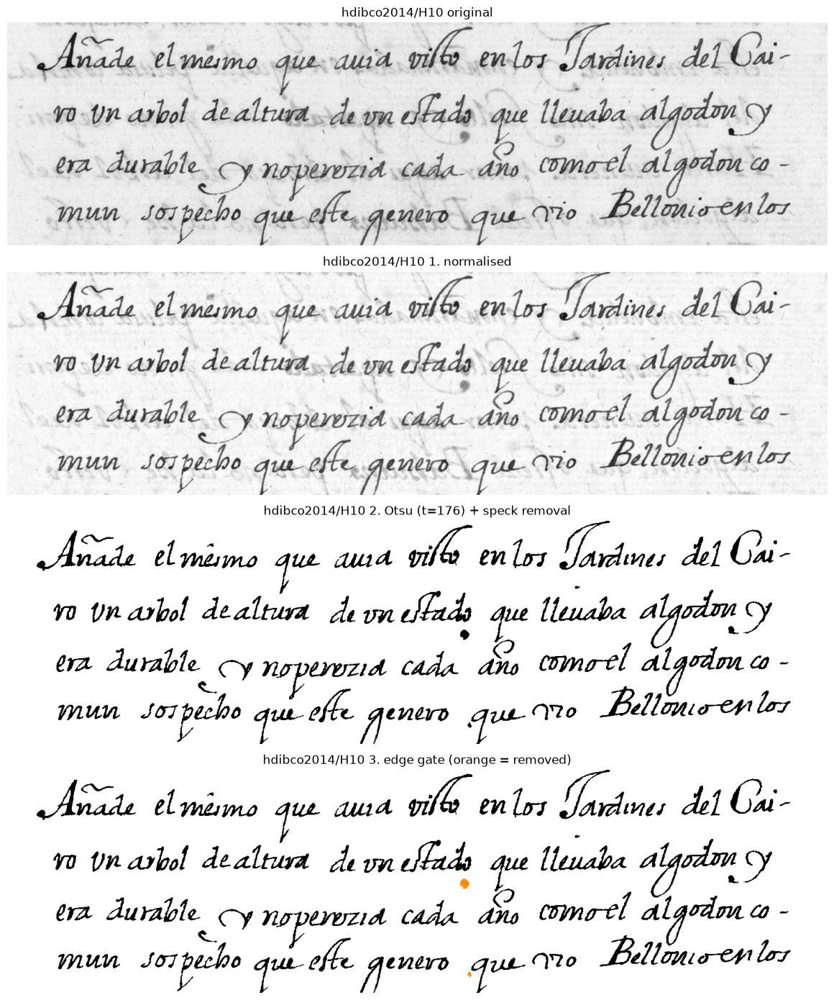

In [10]:
for n in IMAGES:
    img, gt, _ = data[n]
    s = steps[n]
    gate_view = np.full(img.shape + (3,), 255, np.uint8)
    gate_view[preds[n]] = (0, 0, 0)
    gate_view[s['removed_by_gate']] = (255, 140, 0)
    panels = [(img, 'original'), (s['normalised'], '1. normalised'),
              (~s['thresholded'], f"2. Otsu (t={s['otsu_t']:.0f}) + speck removal"),
              (gate_view, '3. edge gate (orange = removed)')]
    fig, ax = plt.subplots(4, 1, figsize=(14, 14)) if is_wide(img) else plt.subplots(1, 4, figsize=(20, 7))
    for a, (im, title) in zip(ax, panels):
        a.imshow(im, cmap='gray'); a.set_title(f'{n} {title}'); a.axis('off')
    plt.tight_layout(); plt.show()

## 6. Errors against the GT

**Black** = correct text, **red** = false positive (ink kept that the GT calls background, e.g. bleed-through or strokes drawn too thick), **blue** = false negative (missed front ink).

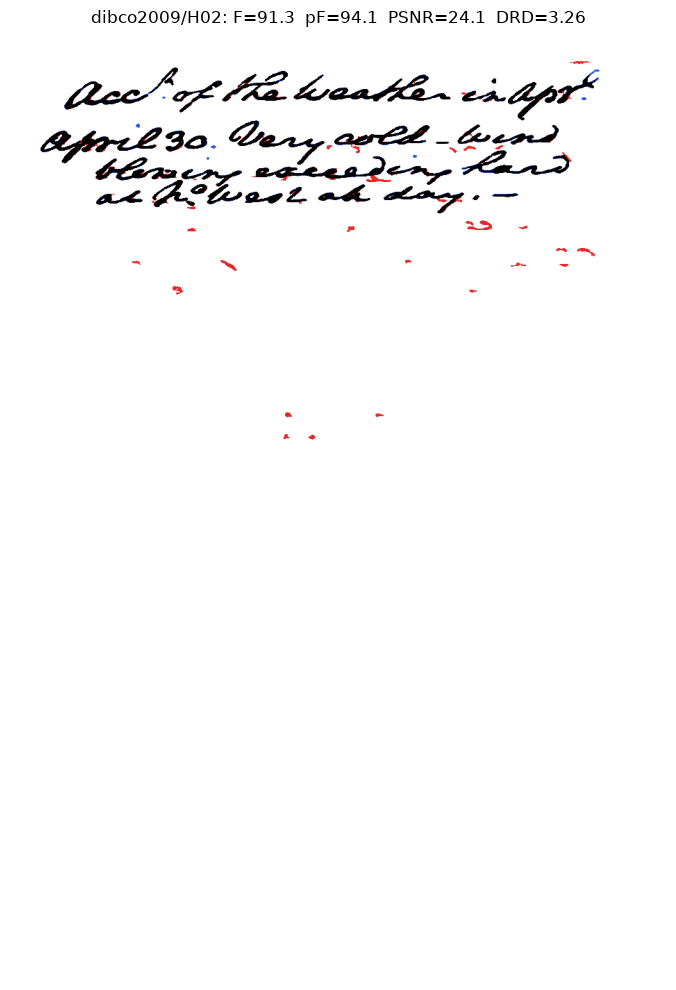

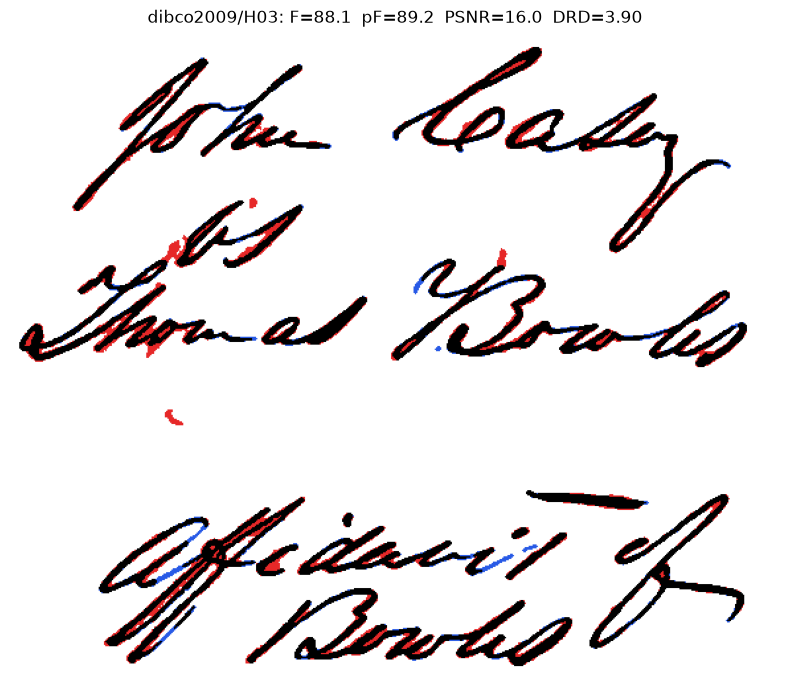

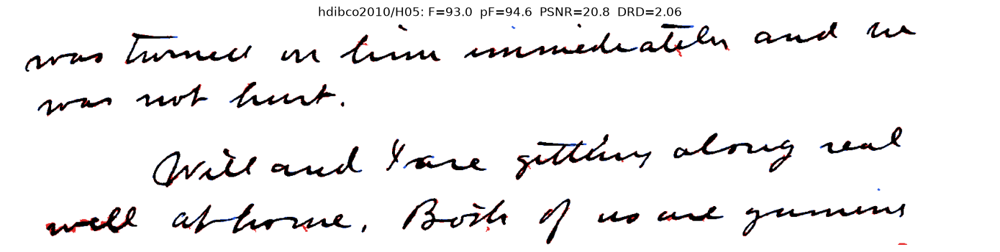

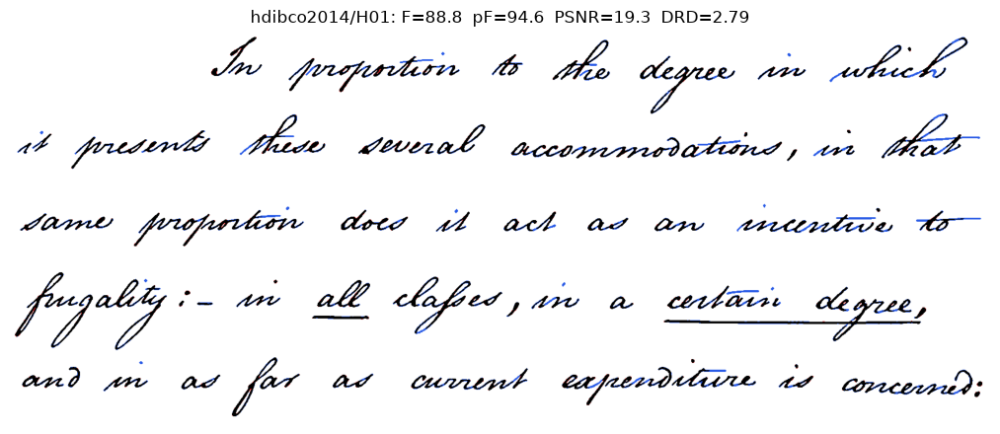

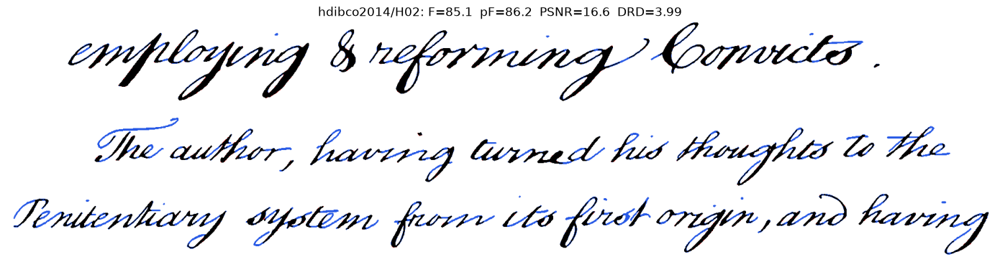

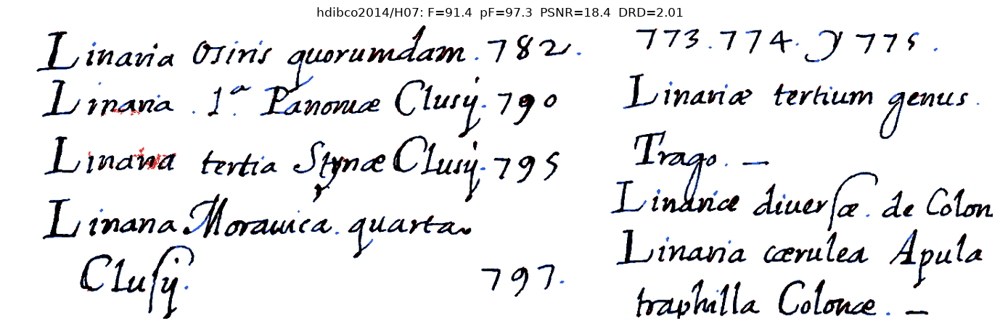

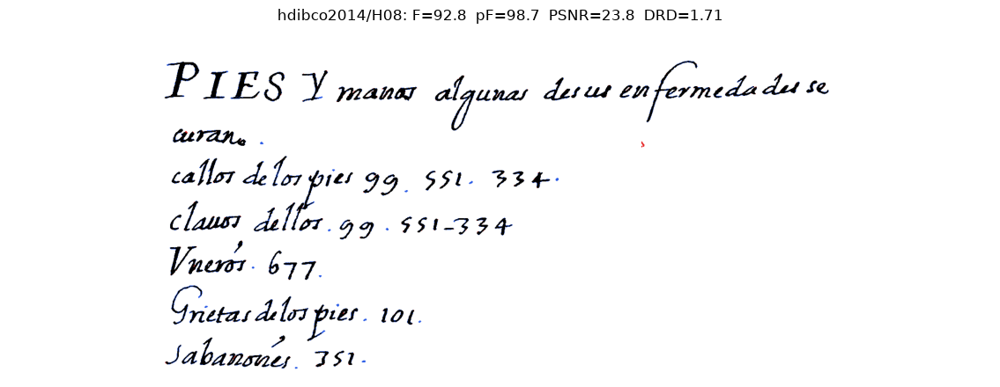

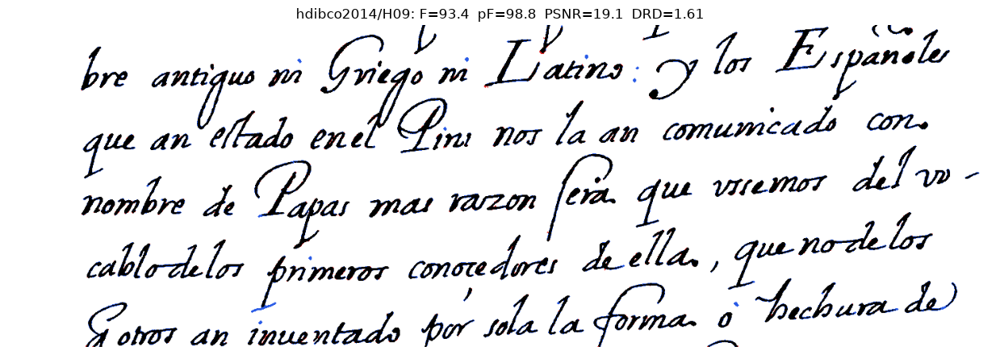

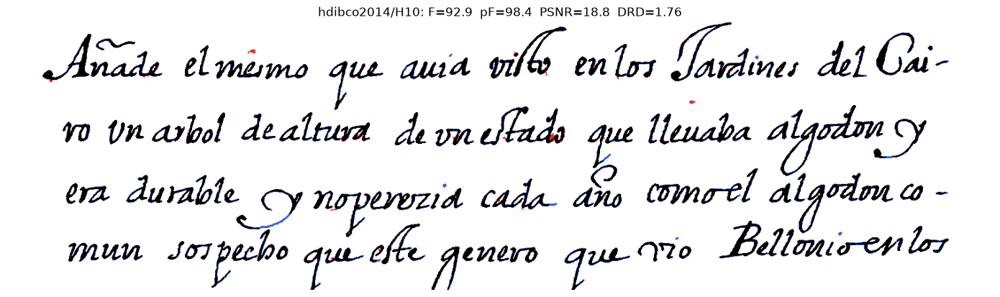

In [11]:
def error_map(pred, gt):
    out = np.full(gt.shape + (3,), 255, np.uint8)
    out[pred & gt] = (0, 0, 0)
    out[pred & ~gt] = (230, 40, 40)
    out[~pred & gt] = (40, 90, 230)
    return out

for n in IMAGES:
    img, gt, _ = data[n]
    s = scores.loc[n]
    plt.figure(figsize=(14, 4.5) if is_wide(img) else (8, 10))
    plt.imshow(error_map(preds[n], gt)); plt.axis('off')
    plt.title(f"{n}: F={s.F:.1f}  pF={s.pF:.1f}  PSNR={s.PSNR:.1f}  DRD={s.DRD:.2f}")
    plt.tight_layout(); plt.show()

## 7. Save outputs

PNGs in GT convention (text = 0, background = 255) go to `joeal_data/output/`, along with CSVs of all scores.

In [12]:
for n in IMAGES:
    cv2.imwrite(str(OUT / f"{n.replace('/', '_')}_binarized.png"), np.where(preds[n], 0, 255).astype(np.uint8))
scores.to_csv(OUT / 'scores_ours.csv')
all_scores.round(2).to_csv(OUT / 'scores_all_methods.csv', index=False)
print('Saved to', OUT.resolve())
print(sorted(p.name for p in OUT.iterdir()))

Saved to /Users/joeal/Library/CloudStorage/OneDrive-Personal/Desktop/CS/Year 4/Semester 1/Image Processing/joeal project/joeal_data/output
['dibco2009_H02_binarized.png', 'dibco2009_H03_binarized.png', 'hdibco2010_H05_binarized.png', 'hdibco2014_H01_binarized.png', 'hdibco2014_H02_binarized.png', 'hdibco2014_H07_binarized.png', 'hdibco2014_H08_binarized.png', 'hdibco2014_H09_binarized.png', 'hdibco2014_H10_binarized.png', 'scores_all_methods.csv', 'scores_ours.csv']


## 8. Observations

- **One fixed technique, nine pages, three datasets:** mean F 90.7, and never below 85.1.
- **Hardest pages:** hdibco2014/H02 (F 85.1) and dibco2009/H03 (F 88.1). Their error maps in section 6 show where it goes wrong.
- **Remaining errors** are mainly strokes drawn a pixel or two thicker than the GT (red edges around letters) and a few dark ghost fragments (isolated red blobs). See section 6.
- **Possible next step:** a stricter edge gate (raise `min_edge_ratio`) or a 1 px erosion to match the GT's thinner strokes.